In [1]:
import os
from pathlib import Path
import sys
from matplotlib import pyplot as plt
sys.path.append('../')  # srcディレクトリをimportできるようにする
from src.my_app.core.MyDataset.FineTuningDataset_v1 import FineTuningDataset_v1
from src.my_app.core.MyDataset import FineTuningDataset_v0
IMAGES_DIR = Path('../../kuzushiji-recognition/char_sep_datas')  # 画像ディレクトリ
GT_JSON_PATH = Path('../../kuzushiji-recognition/char_sep_datas/gt_json.json')    # アノテーションJSON (未使用でもロード例)


# データセット定義

In [2]:
from torch.utils.data import DataLoader
test_doc_id_list = [
    '200021637',
    '100249371',
    '100249537',
    '200005598',
    '200014740',
    '200020019',
    '200021712',
    '200021869'
]
train_dataset = FineTuningDataset_v1(
    test_doc_id=test_doc_id_list,
    test_mode=False,
    images_dir=IMAGES_DIR, 
    json_path=GT_JSON_PATH,
    precompute_gt=True,
    )
test_dataset = FineTuningDataset_v1(
    test_doc_id=test_doc_id_list,
    test_mode=True,
    images_dir=IMAGES_DIR,
    json_path=GT_JSON_PATH,
    precompute_gt=True,
)
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True, num_workers=4, pin_memory=True)


[FineTuningDataset_v1] precompute 完了 in 636156.1 ms  count=6114
[FineTuningDataset_v1] precompute 完了 in 5490.2 ms  count=37


# モデル定義

In [3]:
from src.my_app import UNet, create_optimized_dataloader
from src.my_app import UNet, create_optimized_dataloader
import torch

check_point_version = '1.1'
checkpoint_dir = "../checkpoints"
checkpoint_path = os.path.join(checkpoint_dir, f"latest_checkpoint_V{check_point_version}.pth")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(3, 4).to(device)
def weighted_mse_loss(pred, target, thresh=0.01, pos_weight=20, use_continuous=True, eps=1e-8):
    """
    pred: (B,C,H,W)
    target: (B,C,H,W)
    thresh: 正例二値化の閾値 (use_continuous=False のとき)
    pos_weight: 正例に掛ける重み (または連続重み係数 α)
    use_continuous: Trueなら w = 1 + pos_weight * target（ターゲット値で連続的に重み付け）
    """
    if use_continuous:
        w = 1.0 + pos_weight * target   # target が 0～1 と想定
    else:
        pos = (target > thresh).float()
        w = 1.0 + (pos_weight - 1.0) * pos
    diff2 = (pred - target) ** 2
    loss = (w * diff2).sum() / (w.sum().clamp_min(eps))
    return loss
criterion = weighted_mse_loss # 回帰問題なのでMSE損失を使用 
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
os.makedirs(checkpoint_dir, exist_ok=True)

# 最良のモデルを追跡するための変数
best_test_loss = float('inf')
start_epoch = 0

# 損失の履歴を保存するリストを初期化
train_loss_history = []
test_loss_history = []

# チェックポイントの読み込み（存在する場合）
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = 0
    best_test_loss = checkpoint.get('best_test_loss', float('inf'))
    train_loss_history = checkpoint.get('train_loss_history', train_loss_history)
    test_loss_history  = checkpoint.get('test_loss_history',  test_loss_history)
    print(f"[main]: チェックポイントを読み込みました（エポック {start_epoch}）")
else:
    start_epoch = 0
    best_test_loss = float('inf')
# 以降は train_loss_history / test_loss_history を再初期化しない

def crop_labels_to_match(labels_to_crop, target_tensor):
    target_h, target_w = target_tensor.shape[2:]
    source_h, source_w = labels_to_crop.shape[2:]
    delta_h = (source_h - target_h) // 2
    delta_w = (source_w - target_w) // 2
    return labels_to_crop[:, :, delta_h:delta_h + target_h, delta_w:delta_w + target_w]

[main]: チェックポイントを読み込みました（エポック 0）


## モデル出力チェック


In [ ]:
from tqdm import tqdm
epoch = 0
num_epochs = 1
train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
for batch in train_bar:
    # バッチは (imgs, masks, file_id) 想定
    if len(batch) == 3:
        imgs = batch[0]
        masks = batch[1]
        file_ids = batch[2]
    elif len(batch) == 2:
        imgs = batch[0]
        masks = batch[1]
        file_ids = None
    pred = model(imgs.to(device))
    cropped_imgs = crop_labels_to_match(imgs, pred)
    # for i in range(4):
    #     train_dataset.show_combine_3chanel_and_1chanel(image_A=cropped_imgs[0], image_B=pred[0][i].cpu().detach())

Epoch 1/1 [Train]:   0%|          | 0/35 [00:00<?, ?it/s]

torch.Size([1, 3, 431, 300]) torch.Size([1, 4, 431, 300])


Epoch 1/1 [Train]:   3%|▎         | 1/35 [00:07<04:20,  7.66s/it]

torch.Size([1, 3, 419, 300]) torch.Size([1, 4, 419, 300])


Epoch 1/1 [Train]:   6%|▌         | 2/35 [00:08<02:03,  3.73s/it]

...

Epoch 1/1 [Train]:  94%|█████████▍| 33/35 [00:33<00:01,  1.29it/s]

torch.Size([1, 3, 436, 300]) torch.Size([1, 4, 436, 300])


Epoch 1/1 [Train]:  97%|█████████▋| 34/35 [00:33<00:00,  1.30it/s]

torch.Size([1, 3, 410, 300]) torch.Size([1, 4, 410, 300])


Epoch 1/1 [Train]: 100%|██████████| 35/35 [00:35<00:00,  1.00s/it]


# 学習スタート

[main]: 学習を開始します...
[main]: start epoch 1


Epoch 1/2 [Test]: 100%|██████████| 37/37 [00:40<00:00,  1.09s/it, loss=0.0203]  


[main]: Epoch 1/2 | Train Loss: 0.0260 | Test Loss: 0.0167
[main]: start epoch 2


Epoch 2/2 [Test]: 100%|██████████| 37/37 [00:40<00:00,  1.08s/it, loss=0.0225] 


[main]: Epoch 2/2 | Train Loss: 0.0205 | Test Loss: 0.0244
[main]: 学習が完了しました。


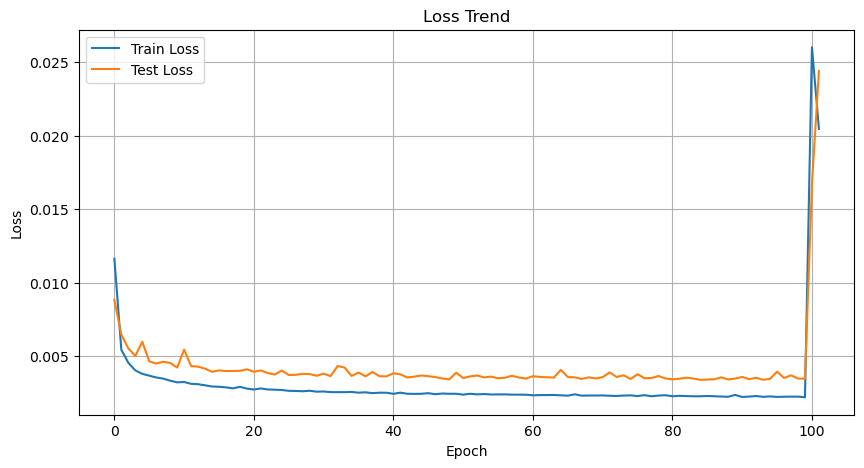

In [4]:
checkpoint_dir_finetuning = "../checkpoints_finetuning"
num_epochs = 2 # エポック数を定義

os.makedirs(checkpoint_dir_finetuning, exist_ok=True)
check_point_version_finetuning = '1.0'

from tqdm import tqdm
print("[main]: 学習を開始します...")
for epoch in range(start_epoch, num_epochs):
    print(f"[main]: start epoch {epoch+1}")
    # --- 訓練フェーズ ---
    model.train() # モデルを訓練モードに設定
    train_loss_total = 0
    
    # tqdmでプログレスバーを表示
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
    for batch in train_bar:
        # バッチは (imgs, masks, file_id) 想定
        if len(batch) == 3:
            imgs = batch[0]
            masks = batch[1]
            file_ids = batch[2]
        elif len(batch) == 2:
            imgs, masks = batch
            file_ids = None
        else:
            raise ValueError(f"Unexpected batch structure len={len(batch)}")
        imgs, masks = imgs.to(device), masks.to(device)
        
        preds = model(imgs)
        cropped_masks = crop_labels_to_match(masks, preds)

        loss = criterion(preds, cropped_masks)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss_total += loss.item()
        # プログレスバーに現在のロスを表示
        train_bar.set_postfix(loss=loss.item())

    avg_train_loss = train_loss_total / len(train_loader)
    train_loss_history.append(avg_train_loss)

    # --- 評価フェーズ ---
    model.eval() # モデルを評価モードに設定
    test_loss_total = 0

    # 勾配計算を無効化して、メモリ効率を良くする
    with torch.no_grad():
        test_bar = tqdm(test_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Test]")
        for batch in test_bar:
            # バッチは (imgs, masks, file_id) 想定
            if len(batch) == 3:
                imgs, masks, file_ids = batch
            elif len(batch) == 2:
                imgs, masks = batch
                file_ids = None
            else:
                raise ValueError(f"Unexpected batch structure len={len(batch)}")
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            cropped_masks = crop_labels_to_match(masks, preds)
            
            loss = criterion(preds, cropped_masks)
            test_loss_total += loss.item()
            test_bar.set_postfix(loss=loss.item())

    avg_test_loss = test_loss_total / len(test_loader)
    test_loss_history.append(avg_test_loss)
    
    # 各エポックの最後に訓練ロスとテストロスを表示
    print(f"[main]: Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}")
    
    # 最新のチェックポイントを保存
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss_history': train_loss_history,
        'test_loss_history': test_loss_history,
        'best_test_loss': best_test_loss
    }, os.path.join(checkpoint_dir_finetuning, f"latest_checkpoint_v{check_point_version_finetuning}.pth"))

    # より良い性能が出た場合、ベストモデルとして保存
    if avg_test_loss < best_test_loss:
        best_test_loss = avg_test_loss
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'test_loss': avg_test_loss,
        }, os.path.join(checkpoint_dir_finetuning, f"best_model_v{check_point_version_finetuning}.pth"))
        print(f"[main]: 新しいベストモデルを保存しました（Test Loss: {avg_test_loss:.4f}）")

print("[main]: 学習が完了しました。")

# --- 損失の推移をグラフで表示 ---
plt.figure(figsize=(10, 5))
plt.plot(train_loss_history, label="Train Loss")
plt.plot(test_loss_history, label="Test Loss")
plt.title("Loss Trend")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()